# MAPS Output Exploration — `maps_output_F1_06_21_2026.nc`

This notebook explores the structure of the MAPS model output file, then computes
value ranges and distributions for each variable.

The file is large (~6.4 GB, CONUS grid at ~3105 x 7025 resolution, 42 time steps),
so it is opened lazily with `xarray` + `dask` and processed in chunks rather than
loaded fully into memory.

In [1]:
import xarray as xr
import dask
import dask.array as da
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NC_PATH = "maps_output_F1_06_21_2026.nc"


## 1. Open the dataset and inspect structure

In [2]:
ds = xr.open_dataset(NC_PATH, chunks={"time": 1, "lat": 1024, "lon": 1024})
ds

/var/folders/rf/k82mzf2173v9psjn1wmn4dfh0000gn/T/ipykernel_50955/3363362417.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(NC_PATH, chunks={"time": 1, "lat": 1024, "lon": 1024})


<xarray.Dataset> Size: 29GB
Dimensions:    (time: 42, lat: 3105, lon: 7025)
Coordinates:
  * time       (time) datetime64[ns] 336B 2026-06-21 2026-06-24 ... 2026-10-22
  * lat        (lat) float64 25kB 24.06 24.07 24.08 24.09 ... 49.91 49.92 49.93
  * lon        (lon) float64 56kB -125.0 -125.0 -125.0 ... -66.5 -66.5 -66.49
Data variables:
    step       (time) int32 168B dask.array<chunksize=(1,), meta=np.ndarray>
    S          (time, lat, lon) float64 7GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    I_total    (time, lat, lon) float64 7GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    D          (time, lat, lon) float64 7GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
    NDI_total  (time, lat, lon) float64 7GB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    title:        MAPS output

In [3]:
print("Global attributes:")
for k, v in ds.attrs.items():
    print(f"  {k}: {v}")

print("\nDimensions:")
for name, size in ds.sizes.items():
    print(f"  {name}: {size}")

print(f"\nlon range: {float(ds.lon.min()):.4f} to {float(ds.lon.max()):.4f} (degrees_east)")
print(f"lat range: {float(ds.lat.min()):.4f} to {float(ds.lat.max()):.4f} (degrees_north)")

t0, t1 = pd.Timestamp(ds.time.values[0]), pd.Timestamp(ds.time.values[-1])
print(f"time: {ds.sizes['time']} steps from {t0.date()} to {t1.date()} "
      f"(step index range: {int(ds.step.values[0])} .. {int(ds.step.values[-1])})")

Global attributes:
  Conventions: CF-1.8
  title: MAPS output

Dimensions:
  time: 42
  lat: 3105
  lon: 7025

lon range: -125.0208 to -66.4875 (degrees_east)
lat range: 24.0625 to 49.9292 (degrees_north)
time: 42 steps from 2026-06-21 to 2026-10-22 (step index range: 0 .. 124)


In [4]:
data_vars = [v for v in ds.data_vars if set(ds[v].dims) >= {"time", "lat", "lon"}]

var_meta = pd.DataFrame([
    {
        "variable": v,
        "long_name": ds[v].attrs.get("long_name", ""),
        "units": ds[v].attrs.get("units", ""),
        "dtype": ds[v].dtype,
        "shape": ds[v].shape,
    }
    for v in data_vars
])
var_meta

,variable,long_name,units,dtype,shape
0,S,susceptible population,,float64,"(42, 3105, 7025)"
1,I_total,total infectious population,,float64,"(42, 3105, 7025)"
2,D,D field,,float64,"(42, 3105, 7025)"
3,NDI_total,new daily infections total,,float64,"(42, 3105, 7025)"


## 2. Value ranges and distributions per variable

For each variable we compute, in a single lazy pass over the data (so the file is
only read once per variable): min, max, mean, std, fraction of exact zeros, NaN
count, and a 50-bin histogram. This takes roughly 15-25s per variable.

In [5]:
N_BINS = 50

stats = {}
histograms = {}

for name in data_vars:
    v = ds[name]
    mn = v.min()
    mx = v.max()
    mean = v.mean()
    std = v.std()
    nan_count = v.isnull().sum()
    zero_count = (v == 0).sum()

    # First pass: get the range so the histogram bins are meaningful
    mn_val, mx_val = dask.compute(mn, mx)
    mn_val, mx_val = float(mn_val), float(mx_val)

    hist = da.histogram(v.data, bins=N_BINS, range=(mn_val, mx_val))

    mean_val, std_val, nan_val, zero_val, (counts, edges) = dask.compute(
        mean, std, nan_count, zero_count, hist
    )

    stats[name] = {
        "min": mn_val,
        "max": mx_val,
        "mean": float(mean_val),
        "std": float(std_val),
        "n_total": v.size,
        "n_nan": int(nan_val),
        "n_zero": int(zero_val),
        "pct_zero": 100 * int(zero_val) / v.size,
    }
    histograms[name] = (counts, edges)
    print(f"done: {name}")

done: S


done: I_total


done: D


done: NDI_total


In [6]:
summary = pd.DataFrame(stats).T
summary

,min,max,mean,std,n_total,n_nan,n_zero,pct_zero
S,0.0,31379.878906,0.656623,12.576524,916130250.0,0.0,678404580.0,74.051106
I_total,0.0,5678.453913,0.761580,13.474113,916130250.0,0.0,719292202.0,78.514185
D,0.0,14935.518306,1.320734,27.137915,916130250.0,0.0,719294170.0,78.514400
NDI_total,0.0,132.538346,0.018417,0.288974,916130250.0,0.0,714493552.0,77.990390


## 3. Distribution plots

Values are heavily right-skewed (population/case-count style fields, many cells
at or near zero — likely ocean/no-population cells outside the land mask), so
counts are shown on a log scale.

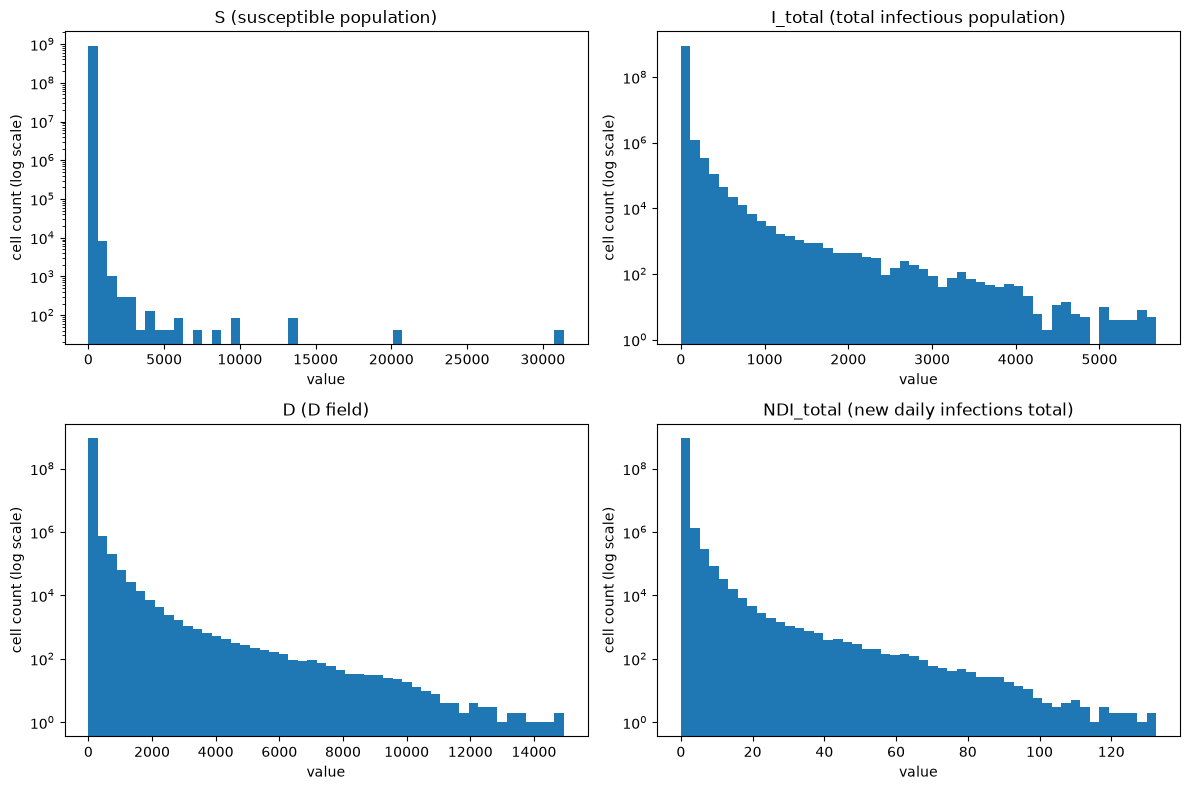

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, name in zip(axes.flat, data_vars):
    counts, edges = histograms[name]
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, counts, width=np.diff(edges), align="center")
    ax.set_yscale("log")
    ax.set_title(f"{name} ({ds[name].attrs.get('long_name', '')})")
    ax.set_xlabel(ds[name].attrs.get("units", "value"))
    ax.set_ylabel("cell count (log scale)")

plt.tight_layout()
plt.show()

## 4. Quick spatial sanity check

One time slice per variable (last time step), plotted at reduced resolution, to
confirm the data looks geographically sensible (CONUS-shaped, no obvious
corruption).

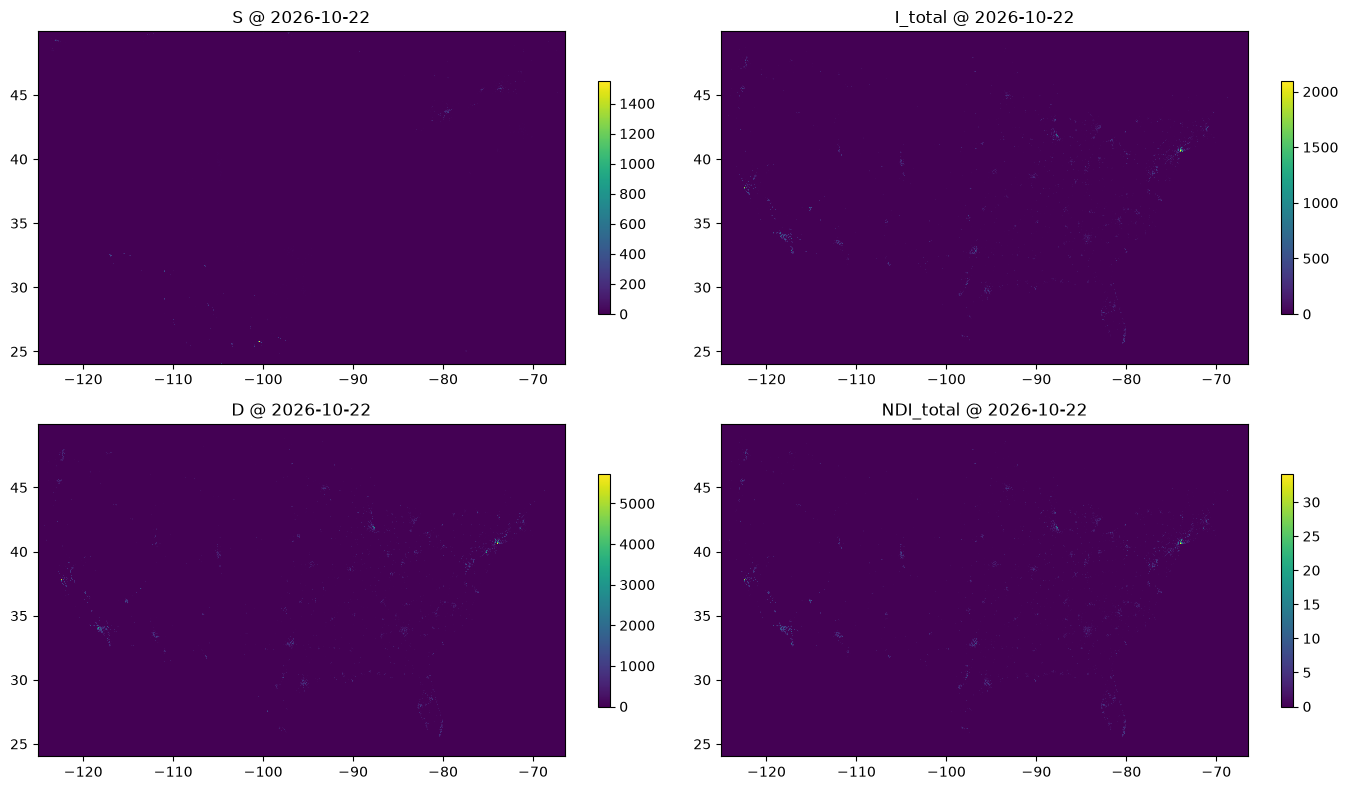

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, name in zip(axes.flat, data_vars):
    # subsample spatially for a fast plot
    snap = ds[name].isel(time=-1, lat=slice(None, None, 8), lon=slice(None, None, 8)).load()
    im = ax.pcolormesh(snap.lon, snap.lat, snap.values, shading="auto")
    ax.set_title(f"{name} @ {pd.Timestamp(ds.time.values[-1]).date()}")
    fig.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

## Notes

- All four variables (`S`, `I_total`, `D`, `NDI_total`) share the same `(time, lat, lon)` grid.
- There is a `variant` dimension (size 14) declared in the file but no variable currently uses it.
- No NaNs were found; a large fraction of cells are exactly zero, consistent with ocean/no-population grid cells within the CONUS bounding box.
- Next steps (aggregation to a region/time series, point extraction, or exporting a smaller subset) can build on the lazy `ds` opened above.

## 5. Export for Kepler.gl

Kepler.gl (browser-based) can't handle the full grid (3105 x 7025 x 42 x 4 vars).
This section builds a long-format CSV suitable for import:

- Spatial downsampling: every 8th grid cell (~389 x 879 -> ~342K cells/step)
- All 42 time steps included, so Kepler's time animation/filter works on the `time` column
- All 4 variables (`S`, `I_total`, `D`, `NDI_total`) as columns
- Rows where all 4 variables are exactly zero are dropped (these are ocean/no-population
  cells outside the land mask - ~74-79% of cells, see Section 2) to keep the file a
  reasonable size
- Coordinates rounded to 4 decimals and values to 3 decimals (further reduces file size
  with negligible precision loss for mapping purposes)

In [9]:
STRIDE = 8  # every 8th grid cell in both lat and lon
OUT_CSV = "maps_output_F1_06_21_2026_kepler.csv"

sub = ds.isel(lat=slice(None, None, STRIDE), lon=slice(None, None, STRIDE))
print(f"Downsampled grid: {sub.sizes['lat']} x {sub.sizes['lon']} "
      f"({sub.sizes['lat'] * sub.sizes['lon']:,} cells/step)")

loaded = sub[["S", "I_total", "D", "NDI_total"]].load()

Downsampled grid: 389 x 879 (341,931 cells/step)


In [10]:
kepler_df = loaded.to_dataframe().reset_index()

nonzero_mask = (
    (kepler_df["S"] != 0)
    | (kepler_df["I_total"] != 0)
    | (kepler_df["D"] != 0)
    | (kepler_df["NDI_total"] != 0)
)
kepler_df = kepler_df[nonzero_mask].copy()

kepler_df["lat"] = kepler_df["lat"].round(4)
kepler_df["lon"] = kepler_df["lon"].round(4)
for col in ["S", "I_total", "D", "NDI_total"]:
    kepler_df[col] = kepler_df[col].round(3)
kepler_df["time"] = kepler_df["time"].dt.strftime("%Y-%m-%d")

print(f"{len(kepler_df):,} rows after dropping all-zero cells "
      f"({len(kepler_df) / (loaded.sizes['time'] * loaded.sizes['lat'] * loaded.sizes['lon']):.1%} kept)")
kepler_df.head()

3,709,188 rows after dropping all-zero cells (25.8% kept)


,time,lat,lon,S,I_total,D,NDI_total
219,2026-06-21,24.0625,-110.4208,1.458,0.0,0.0,0.0
220,2026-06-21,24.0625,-110.3542,1.458,0.0,0.0,0.0
221,2026-06-21,24.0625,-110.2875,8.233,0.0,0.0,0.0
222,2026-06-21,24.0625,-110.2208,0.064,0.0,0.0,0.0
223,2026-06-21,24.0625,-110.1542,0.057,0.0,0.0,0.0


In [11]:
kepler_df.to_csv(OUT_CSV, index=False)
print(f"wrote {OUT_CSV}")

wrote maps_output_F1_06_21_2026_kepler.csv


### Importing into Kepler.gl

1. Go to [kepler.gl/demo](https://kepler.gl/demo) and drag in `maps_output_F1_06_21_2026_kepler.csv`.
2. Kepler should auto-detect `lat`/`lon` as a Point layer and `time` as a time field.
3. Use the **Filters** panel to add a filter on `time` and enable time-based animation/playback.
4. Use the layer color/size "based on" dropdown to color/size points by `NDI_total`, `I_total`, `S`, or `D`.
5. If it still feels slow in the browser, re-run Section 5 with a larger `STRIDE` (e.g. 16) for a lighter file.